# Classificazione di tumori benigni e maligni

**Cardillo Antonino - Ragazzini Manuel**


# 1. Introduzione del problema e Presentazione del Dataset

- **Il problema affrontato:** L'obiettivo principale di questo studio è addestrare e confrontare diversi modelli di apprendimento automatico per l'identificazione precoce e accurata dei tumori al seno, effettuando una classificazione tra masse benigne e maligne.

- **I task che seguiremo nel progetto:**
    1. Descrizione e analisi iniziale del dataset.
    2. Pulizia dei dati (rimozione di informazioni amministrative o nulle).
    3. Analisi Esplorativa dei Dati (EDA) tramite calcolo delle statistiche descrittive e visualizzazione grafica.
    4. Outlier Detection (rilevamento dei valori anomali).
    5. Preprocessing finale e bilanciamento dei dati (Train/Test Split e Standardizzazione).
    6. Classificazione Supervisionata tramite il confronto di quattro differenti algoritmi (Modelli Lineari, Geometrici, Ensemble e Reti Neurali).

- **L'obiettivo del progetto:** Vogliamo dimostrare numericamente e graficamente che le cellule maligne presentano caratteristiche morfologiche (come dimensione, accrescimento ed irregolarità dei contorni) nettamente superiori e più caotiche rispetto a quelle benigne, sfruttando questa separazione per massimizzare la precisione diagnostica in entrambi i casi.

- **L'interesse pratico e applicativo:** In ambito oncologico, l'utilità di questo sistema risiede nella capacità di supportare il personale medico fornendo una diagnosi altamente affidabile. Dal punto di vista delle metriche, l'interesse principale è massimizzare la sensibilità (Recall) per ridurre al minimo i **falsi negativi**: mandare a casa una paziente malata con una diagnosi erroneamente sana rappresenta il rischio più grave in assoluto. Di riflesso, si cercherà di mantenere alta la precisione per limitare i falsi positivi, evitando stress psicologici e interventi non necessari su pazienti sane.


# 2. Descrizione del dataset

Il dataset è stato recuperato al seguente link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

Le variabili presenti nel DataSet rappresentano la trasformazione delle caratteristiche geometriche dei nuclei cellulari estratti da biopsie in valori numerici. Alcune delle principali differenze tra una cellula maligna e una benigna sono: dimensione, linearità del perimetro, simmetria, regolarità della superfice, valore frattale. Troviamo 569 righe e 33 colonne compreso id paziente e una colonna vuota, queste identificano la media (_mean), l'errore standard (_se) e la media dei tre valori più grandi (_worst).
La veriabile target in questo dataset è senza dubbio la diagnosi (diagnosis) che può avere valore (M)aligno o (B)enigno e possiamo dedurre che abbiamo una classificazione binaria. 
    

# 3. Lettura e preparazione dei dati

Importazione delle librerie

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy import stats


Importiamo il dataset

In [94]:
file_path = "cancer.csv"
df = pd.read_csv(file_path)

Visualizziamo le prime righe del dataset

In [95]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


Controlliamo le dimensioni del dataset

In [96]:
df.shape

(569, 33)

Estraiamo i nomi delle colonne e il tipo

In [97]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

Notiamo che la colonna diagnosis ha come tipo object in quanto i valori che ritroveremo sono non di tipo numerico ma il carattere M ed il carattere B, in sguito saranno convertiti rispettivamente in 1 e 0 

Prima di proseguire facciamo un ulteriore controllo sul contenuto nullo di ogni colonna anche se dallo shape già abbiamo ricavato il valore non-null count. Un valore nullo negli algoritmi tipo Logistic Regression bloccano o danno errori.

In [98]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In entrambi i casi troviamo una colonna con etichetta 'Unnamed: 32' che non contiene dati, in realtà è una colonna vuota e che pandas le assegna quella etichetta. A questo punto la eliminiamo e cogliamo l'occasione per eliminare anche la colonna 'id' in quanto ci riporta solo dei valori sequenziali, il riferimento al paziente, che non utilizziamo nella nostra analisi. 

In [99]:
df=df.drop(columns=['id','Unnamed: 32'], errors='ignore')
#df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    object 
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  5

# 4. Visualizzazione ed EDA
Abbiamo ripulito il dataset, ora controlliamo di quanto è sbilanciato, nel caso sia troppo sbilanciato, i modelli che alleneremo tenderanno a predire la diagnosi che ha la percentuale più alta e maggiormente sbilanciata. Procediamo facendo un conteggio delle occorrenze del valore M e del valore B della colonna diagnosis e poi calcoliamo la percentuale. 

Conteggio:

In [100]:
conteggio = df['diagnosis'].value_counts()
conteggio

diagnosis
B    357
M    212
Name: count, dtype: int64

Percentuale:

In [101]:
percentuale=df['diagnosis'].value_counts(normalize=True)*100
percentuale

diagnosis
B    62.741652
M    37.258348
Name: proportion, dtype: float64

Sia nel conteggio che nella rappresentazione in percentuale, il dataset risulta avere un giusto sbilanciamento, entrambi si avvicinano al 50%

Visualizziamo dal punto di vista statistico il dataset

In [102]:
df.describe()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


Il dataset è composto da 30 caratteristiche, queste si suddividono in tre macro sezioni che sono le medie, gli errori standard e la media dei tre valori più grandi.
Si decide volutamente di utilizzare le metriche medie (`_mean`) in questa fase iniziale per ottenere una panoramica sul comportamento statistico generale del campione, rimandando l'analisi delle metriche d'errore (`_se`) e di picco (`_worst`) alla successiva fase di modellazione predittiva.
Per non avere ridondanza di dati e a colpo d'occhio evidenziare le differenze, possiamo selezionare una caratteristica geometrica per ognuna di queste tre sezioni: 
1. **Dimensione:** (area_mean) come indicatore della volumetria cellulare.
2. **Forma/Rugosità:** (texture_mean) come indicatore delle proprietà di superficie e rifrazione del nucleo.
3. **Irregolarità dei contorni:** (concavity_mean) come indicatore del livello di deformazione dei contorni.


Vediamo prima dal punto di vista numerico la relazione tra queste caratteristiche, raggruppiamo le medie per ogni classe/famiglia, le stampiamo a video, dopo le rappresenteremo graficamente con i boxplot.

In [103]:
medie_per_classe = df.groupby('diagnosis').mean()
colonne_chiave = ['area_mean', 'texture_mean', 'concavity_mean']

print("--- CONFRONTO DELLE MEDIE CLINICHE ---")
print(medie_per_classe[colonne_chiave])

--- CONFRONTO DELLE MEDIE CLINICHE ---
            area_mean  texture_mean  concavity_mean
diagnosis                                          
B          462.790196     17.914762        0.046058
M          978.376415     21.604906        0.160775


Notiamo che la media delle aree dei maligni è quasi il doppio dei benigni, questo ci fa capire che è una delle caratteristiche giusta per il confronto, la concavità anche quella ha una differenza abbastanza forte considerando 0 = perfettamente convesso, 1 = massima concavità.

Di seguito graficamente con dei boxplot rappresentiamo le tre colonne delle caratteristiche scelte. Sull'asse delle X le diagnosi e sull'asse delle Y le caratteristiche. 

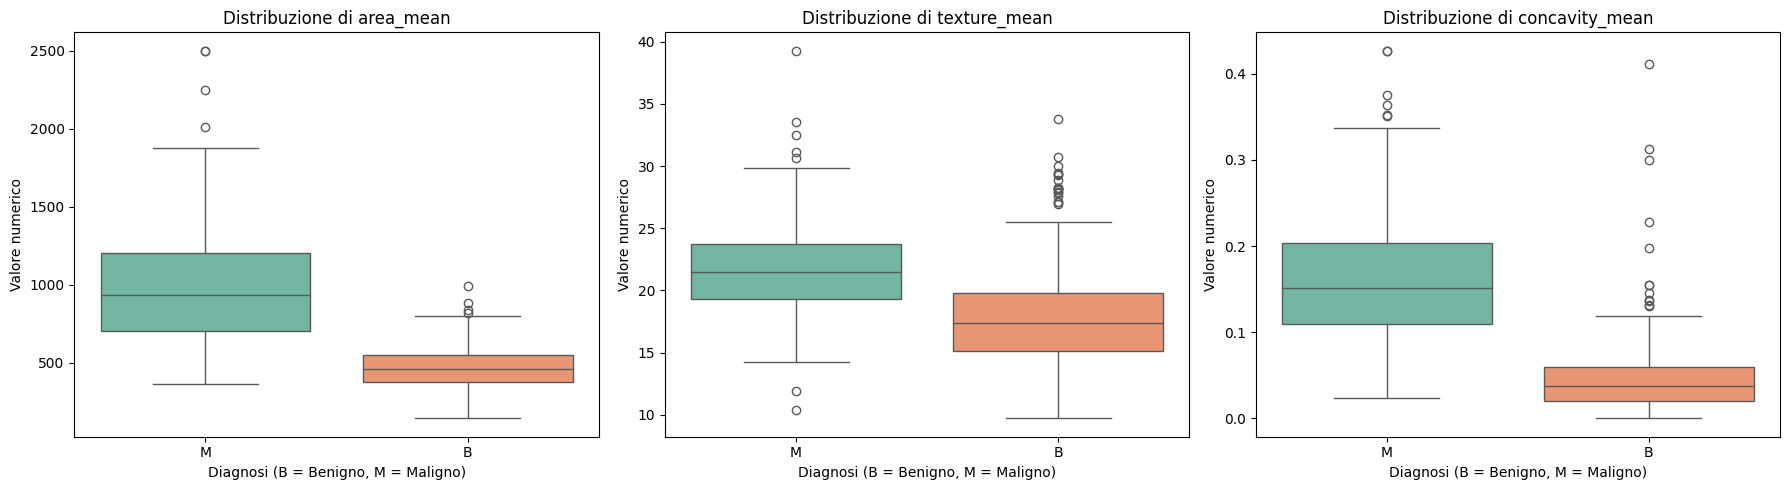

In [104]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

rappresentanti = ['area_mean', 'texture_mean', 'concavity_mean']

for i, feature in enumerate(rappresentanti):
    sns.boxplot(ax=axes[i], x='diagnosis', y=feature, data=df, hue='diagnosis', palette='Set2', legend=False)
    axes[i].set_title(f'Distribuzione di {feature}')
    axes[i].set_xlabel('Diagnosi (B = Benigno, M = Maligno)')
    axes[i].set_ylabel('Valore numerico')

plt.tight_layout()
plt.show()

Dal grafico si evidenzia che per la media dell'area i Maligni sono più grandi, hanno valori che vanno da circa 750 a 1200 mentre i Benigni hanno dimensioni che vanno da circa 250 a 750. Stessa cosa la notiamo per la caratteristica della concavità. Analizzando ancora il grafico si vede che nei BoxPlot area_mean e concavity_mean si vede da subito una netta distinsione tra i Maligni e i Benigni, mentre texture_mean in parte si sovrappongono. La suddivisione netta ci fa pensare che possiamo usare un modello di regressione logistica. Altra cosa da notare e da non sottovalutare è che le scale di ogni cartteristica è diversa, dovremo effettuare uno scaling. Infine possiamo vedere anche che sono presenti degli outlier rappresentati dai cerchietti oltre i baffi del grafico.  

Eventuali correlazioni

Per evidenziare eventuali correlazioni tra le caratteristiche usiamo il metodo corr() di pandas. Prima selezioniamo di nuovo i nostri 3 rappresentanti delle famiglie per vedere come correlano tra loro

In [105]:

rappresentanti = ['area_mean', 'texture_mean', 'concavity_mean']

tabella_correlazione = df[rappresentanti].corr()

print("--- MATRICE DI CORRELAZIONE NUMERICA ---")
print(tabella_correlazione)

--- MATRICE DI CORRELAZIONE NUMERICA ---
                area_mean  texture_mean  concavity_mean
area_mean        1.000000      0.321086        0.685983
texture_mean     0.321086      1.000000        0.302418
concavity_mean   0.685983      0.302418        1.000000


Osserviamo la Matrice di Correlazione Numerica

Gli indici di correlazione di Pearson, che vanno da -1 a +1 ,estratti sui tre rappresentanti delle famiglie di caratteristiche, vediamo che tra area e concavità c'è una forte relazione, che al crescere dell'area cresce anche la concavità, ci avviciniamo molto al valore 1 mentre la relazione tra la texture ed entrambe le altre due caratteristiche è molto più bassa, questo ci fa capire che è indipendente dalle altre. 

# 5. Outlier detection / preprocessing
    
Preparazione dei dati per i modelli.

Come primo passo trasformiamo il target Diagnosis che ha come  valori attuali 'M' e 'B' in numerico (1 e 0)".

In [106]:
mappa_diagnosi = {'M': 1, 'B': 0}
df['diagnosis'] = df['diagnosis'].replace(mappa_diagnosi).infer_objects(copy=False)
df['diagnosis'].head()

C:\Users\antonino.cardillo\AppData\Local\Temp\ipykernel_19812\1761074491.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['diagnosis'] = df['diagnosis'].replace(mappa_diagnosi).infer_objects(copy=False)


0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

## Identifichiamo gli Outlier
Per identificare e isolare gli outlier useremo lo Z-Score Standard, che si basa sulla media e deviazione standard, sulle nostre feature per identificare quali righe superano la soglia critica di 3 deviazioni standard dalla media, questo valore normalmente viene considerato statisticamente un'anomalia estrema.



Escludiamo la colonna target diagnosis che non ci viene utile
nel calcolo dello Z-Score.
Il calcolo lo faremo sul'intero dataset e non solo su determinate caratteristiche.

In [107]:
feature_cols = [col for col in df.columns if col != 'diagnosis']

CAlcoliamo lo z-score

In [108]:
z_scores = np.abs(stats.zscore(df[feature_cols]))

Evidenziamo quale caratteristica ha il valore superiore o inferiore a 3 deviazioni standard e quindi quali pazienti.

In [109]:
righe_outlier = np.where(z_scores > 3)[0]

Potrebbe essere che una paziente abbia non una sola caratteristica che identificata come outlier ma più di una quindi per non avere più volte la stessa paziente andiamo a prenderla una sola volta usando unique

In [110]:
righe_outlier_uniche = np.unique(righe_outlier)



Stampiamo i risultati

In [111]:
print(f"Numero di pazienti totali nel dataset: {df.shape[0]}")
print(f"Numero di pazienti identificati come outlier : {len(righe_outlier_uniche)}")

Numero di pazienti totali nel dataset: 569
Numero di pazienti identificati come outlier : 74


L'analisi tramite **Z-Score Standard** ha individuato 74 record considerati outlier, pari a circa il 13% del dataset. Dopo aver analizzato questi risultati, si è deciso di **mantenere tutti i valori**, senza eliminarli (*dropping*) né modificarli (*clipping*).

La scelta è stata fatta per i seguenti motivi:

1. Gli outlier rappresentano casi reali e nel contesto della diagnosi del tumore al seno, valori molto elevati di alcune caratteristiche delle cellule non sono necessariamente errori o anomalie dovute alla raccolta dei dati. Al contrario, possono rappresentare casi clinici realmente più gravi e quindi contenere informazioni importanti per distinguere tumori benigni e maligni.

2. Rimuovere circa il 13% dei dati significherebbe perdere proprio gli esempi più rappresentativi dei casi maligni. Questo potrebbe rendere più difficile per gli algoritmi riconoscere tali situazioni e aumentare il numero di falsi negativi, cioè tumori maligni classificati erroneamente come benigni.

3. Alcuni algoritmi sono sensibili alla presenza di valori estremi, ma questo problema sarà gestito nella fase di pre-processing applicando lo **StandardScaler**, che porta tutte le variabili sulla stessa scala senza eliminare le informazioni contenute negli outlier.

Per questi motivi si è ritenuto più opportuno conservare tutti i record del dataset, mantenendo intatta l'informazione originale e consentendo ai modelli di apprendere anche dai casi clinicamente più significativi.



# 6. Implementazione di uno o più modelli
Implementazione di uno o più modelli

In questa sezione andiamo ad addestrare e confrontare quattro differenti architetture di Machine Learning analizzate durante il corso, coprendo modelli lineari, geometrici, probabilistici e connessionisti:
* Logistic Regression (Modello Lineare):
 Scelta perché l'EDA ha mostrato una buona separabilità geometrica delle classi nei boxplot.
* Support Vector Machines - SVM (Modello Geometrico):
 Ottimo per massimizzare il margine di separazione tra Benigni e Maligni in spazi multidimensionali.
* Random Forest (Modello basato su Alberi):
 Scelto perché non risente della multicollinearità tra raggio/area/perimetro che sono per forza di cose correlati fortemente tra loro ed è **robusto in presenza di outlier**.
* Multi-Layer Perceptron - MLP (Rete Neurale Artificiale):
Scelta per catturare eventuali relazioni non lineari complesse tra le caratteristiche geometriche delle cellule.


Prima di addestrare i modelli, il dataset viene suddiviso in due parti: un Train Set (80%), utilizzato per l'apprendimento degli algoritmi, e un Test Set (20%), impiegato esclusivamente per valutare le prestazioni del modello su dati mai visti in precedenza.

Per garantire una valutazione corretta e affidabile vengono adottati due accorgimenti.

Suddivisione stratificata (stratify=y). Il dataset non è perfettamente bilanciato, poiché contiene circa il 63% di casi benigni e il 37% di casi maligni. Utilizzando la stratificazione, entrambe le suddivisioni mantengono la stessa proporzione delle due classi, rendendo il confronto tra fase di addestramento e fase di test più rappresentativo.

Prevenire il Data Leakage. Prima dell'addestramento viene applicato lo StandardScaler per standardizzare le variabili. Per evitare che il modello utilizzi informazioni provenienti dal Test Set durante l'apprendimento, lo scaler viene addestrato (fit) solo sui dati del Train Set. Gli stessi parametri ottenuti vengono poi utilizzati per trasformare sia il Train Set sia il Test Set (transform). In questo modo il Test Set rimane completamente indipendente e rappresenta una verifica imparziale delle prestazioni del modello.

Questa procedura permette di ottenere una valutazione più realistica delle capacità di generalizzazione degli algoritmi e riduce il rischio di ottenere risultati artificialmente ottimistici.

Come prima cosa separiamo Caratteristiche (X) dal Target (y)

In [112]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

Effettuiamo lo split Train/Test (80% / 20%) con stratificazione

In [113]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Inizializziamo lo StandardScaler

In [114]:
scaler = StandardScaler()

Scaliamo le caratteristiche in modo differenziato per evitare il Data Leakage

In [115]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Verifichiamo

In [116]:
print("--- VERIFICA FINALE DELLE DIMENSIONI ---")
print(f"Pazienti nel Train Set (X_train_scaled): {X_train_scaled.shape[0]}")
print(f"Pazienti nel Test Set (X_test_scaled): {X_test_scaled.shape[0]}")
print(f"Numero di feature in input per ogni paziente: {X_train_scaled.shape[1]}")

--- VERIFICA FINALE DELLE DIMENSIONI ---
Pazienti nel Train Set (X_train_scaled): 455
Pazienti nel Test Set (X_test_scaled): 114
Numero di feature in input per ogni paziente: 30


## Primo modello: Logistic Regression

Importiamo le librerie del modello e le metriche

In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

Inizializziamo il modello (usiamo random_state per la riproducibilità)

In [118]:
lr_model = LogisticRegression(random_state=42, max_iter=1000)

Addestriamo il modello sui dati scalati del Train Set

In [119]:
lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

Facciamo le predizioni sui dati del Test Set e stampiamo il report di classificazione.

In [120]:
y_pred_lr = lr_model.predict(X_test_scaled)

print("--- PERFORMANCE LOGISTIC REGRESSION (TEST SET) ---")
print(classification_report(y_test, y_pred_lr))

--- PERFORMANCE LOGISTIC REGRESSION (TEST SET) ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



Interpretiamo i coifficienti facendo un'estrazione e associandoli ai nomi delle colonne originali

In [121]:
pesi_features = pd.DataFrame({
    'Feature': X.columns,
    'Coefficiente (Peso)': lr_model.coef_[0]
})

Ordiniamo i pesi dal più influente al meno influente per la classe 1 (Maligno)

In [122]:
pesi_features = pesi_features.sort_values(by='Coefficiente (Peso)', ascending=False)

Stampiamo e confrontiamo sia le prime 5 che le ultime 5 con head() e tail()

In [123]:
print("--- PESI DELLE CARATTERISTICHE NELLA LOGISTIC REGRESSION ---")
print(pesi_features.head(5)) 
print("\n...")
print(pesi_features.tail(5))

--- PESI DELLE CARATTERISTICHE NELLA LOGISTIC REGRESSION ---
                Feature  Coefficiente (Peso)
21        texture_worst             1.434093
10            radius_se             1.233325
28       symmetry_worst             1.061264
7   concave points_mean             0.952813
26      concavity_worst             0.911406

...
                 Feature  Coefficiente (Peso)
18           symmetry_se            -0.330658
11            texture_se            -0.407611
5       compactness_mean            -0.439546
19  fractal_dimension_se            -0.593876
15        compactness_se            -0.906925


L'estrazione dei coefficienti della Logistic Regression ci fa notare che le caratteristiche prese in esame nell'EDA ritornano anche se non come _mean dei valori ma _worst dei valori. Infatti tra i più pesanti ritroviamo sia texture che concavity.

Notiamo anche che viene evidenziato il valore della diversità del raggio delle cellule (standard error) quindi la variabilità nello stesso tessuto, anche questo può essere considerato un biomarcatore tumorale maligno.


## Secondo modello: SVM
Proviamo a capire se si riesce a fare una predizione migliore.
Questo modello cerca di determinare un iperpiano di separazione tra le caratteristiche, nel nostro caso in due classi. Utilizziamo un kernel lineare in quanto abbiamo già assodato che le due classi sono divisibili bene.  

Importiamo la libreria e inizializziamo il modello con il kernel lineare e il random_state impostato a 42

In [124]:
from sklearn.svm import SVC
svm_model = SVC(kernel='linear', random_state=42, probability=True)

Addestriamo il modello sui dati del Train Set scalati e effettuiamo la predizione sui dati del Test Set

In [125]:
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

Stampiamo il report di predizione di SVM

In [126]:
print("--- PERFORMANCE SUPPORT VECTOR MACHINE (TEST SET) ---")
print(classification_report(y_test, y_pred_svm))

--- PERFORMANCE SUPPORT VECTOR MACHINE (TEST SET) ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



Entrambi i modelli si sono comportati in modo quasi identico sul piano dell'accuratezza globale (96%), ma la vera differenza emerge dall'analisi della Recall (sensibilità). Un valore di Recall più elevato è fondamentale in questo contesto perché ci permette di ridurre al minimo i **falsi negativi**, evitando così il rischio gravissimo di considerare sana una paziente che in realtà è affetta da un tumore maligno. 

## Terzo modello: Random Forest
Questo modello che andremo ad addestrare per valutarne le performance è la **Random Forest**. A differenza dei primi due, questo non è un modello lineare: si tratta di un algoritmo basato su alberi di decisione, più robusto in presenza di outlier e capace di gestire la forte correlazione tra le caratteristiche geometriche senza subire alterazione nei risultati.

Utilizzeremo la ricerca degli iperparametri migliori con la libreria sklearn GridSearchCV per ottimizzare il modello.

Importiamo la libreria del modello RandomForest e GridSearchCV

In [127]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

Definiamo la griglia di parametri da testare

In [128]:
param_grid_rf = {
    'n_estimators': [50, 100, 200],       # Numero di alberi nella foresta
    'max_depth': [None, 5, 10],            # Massima profondità degli alberi
    'criterion': ['gini', 'entropy']       # Metrica per misurare la qualità dello split
}

Inizializziamo GridSearchCV impostando la RECALL come obiettivo primario
cv=5 significa che farà una Cross-Validation a 5 pieghe per essere matematicamente sicuro del risultato

In [129]:
grid_rf = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                       param_grid=param_grid_rf, 
                       scoring='recall', 
                       cv=5,
                       n_jobs=-1)

Avviamo la ricerca della combinazione migliore sul Train Set scalato

In [130]:
grid_rf.fit(X_train_scaled, y_train)

print("--- RISULTATI OTTIMIZZAZIONE RANDOM FOREST ---")
print(f"Migliori iperparametri trovati: {grid_rf.best_params_}\n")

--- RISULTATI OTTIMIZZAZIONE RANDOM FOREST ---
Migliori iperparametri trovati: {'criterion': 'gini', 'max_depth': None, 'n_estimators': 50}



Estraiamo il modello migliore e facciamo le predizioni sul Test Set

In [131]:
best_rf_model = grid_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test_scaled)

Stampiamo il report di classificazine

In [132]:
print("--- PERFORMANCE RANDOM FOREST OTTIMIZZATA (TEST SET) ---")
print(classification_report(y_test, y_pred_rf))

--- PERFORMANCE RANDOM FOREST OTTIMIZZATA (TEST SET) ---
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



Il fatto stesso che questo modello, come già avevamo accennato, non soffra delle correlazioni tra le caratteristiche grazie al suo modo di analizzare i dati, gli ha permesso di performare meglio. A conferma di ciò, abbiamo implementato un'ottimizzazione tramite GridSearchCV con Cross-Validation a 5 pieghe, impostando la Recall come obiettivo.

La ricerca automatica ha stabilito che la configurazione ideale per il nostro dataset prevede la generazione di 50 alberi (invece dei 100 standard) e l'utilizzo dell'indice di impurità di Gini (criterion: 'gini') come criterio matematico per effettuare i tagli e le decisioni nei singoli nodi.

Questo modello ottimizzato ha raggiunto un F1-score del 96% (contro il 95% degli altri due modelli), riuscendo inoltre a unire il meglio dei due approcci lineari: la Precision del 100% della SVM e la Recall del 93% della Logistic Regression, dimostrando che la foresta decisionale è l'algoritmo più solido ed equilibrato per questo tipo di dati tabulari."

## Quarto ed ultimo modello: MLP (Multi-Layer Perceptrons)
Questo modello è una rete neurale multi layer.

Come per tutti i modelli importiamo le librerie e inizializziamo creando un livello nascosto con 50 nuroni, usiamo l'attivazione 'relu' e max_iter=1000 per farlo convergere e ottimizzatore 'adam' (necessario per tracciare la curva di apprendimento)

In [133]:
from sklearn.neural_network import MLPClassifier
mlp_model = MLPClassifier(hidden_layer_sizes=(50,), activation='relu', solver='adam', random_state=42, max_iter=1000)

Addestriamo la rete neurale sui dati scalati

In [134]:
mlp_model.fit(X_train_scaled, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(50,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


GRAFICO DELLA LEARNING CURVE (LOSS CURVE)

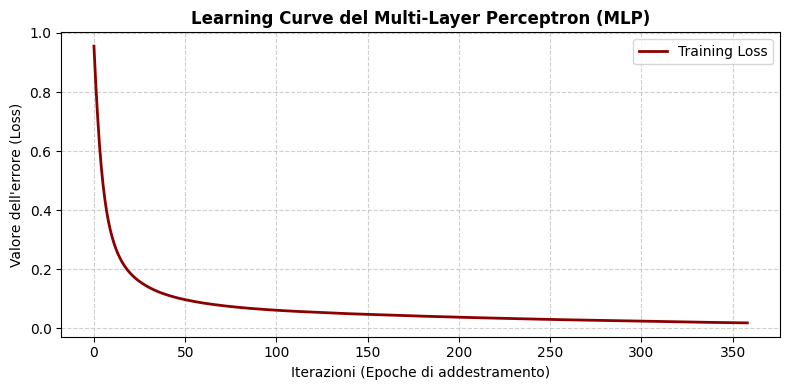

In [135]:
plt.figure(figsize=(8, 4))
plt.plot(mlp_model.loss_curve_, color='darkred', lw=2, label='Training Loss')
plt.title('Learning Curve del Multi-Layer Perceptron (MLP)', fontsize=12, fontweight='bold')
plt.xlabel('Iterazioni (Epoche di addestramento)', fontsize=10)
plt.ylabel('Valore dell\'errore (Loss)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Analisi della Curva del Multi-Layer Perceptron (MLP)

Il grafico soprastante mostra l'andamento della Funzione di Perdita (Loss) del modello MLP lungo le iterazioni di addestramento, fornendo informazioni importanti sulla qualità dell'apprendimento:

1. **Fase di Discesa Rapida (Epoche 0-50):** Nelle prime 50 epoche si osserva un crollo verticale dell'errore, che passa da circa 0.98 a 0.10. Questo comportamento indica che l'ottimizzatore (*Adam*) ha individuato rapidamente la direzione corretta del gradiente, permettendo ai neuroni di sintonizzarsi subito sui pattern morfologici principali (come le dimensioni e la concavità delle cellule).
2. **Fase di Stabilizzazione e Convergenza (Epoche 50-350):** Dall'epoca 50 in poi, la curva si appiattisce progressivamente avvicinandosi in modo asintotico allo zero. La totale assenza di rimbalzi o oscillazioni (che indicherebbero instabilità) e la mancata risalita dell'errore (sintomo tipico di Overfitting) dimostrano che la rete neurale ha raggiunto una convergenza stabile.

Effettuiamo la predizione dul Test Set

In [136]:
y_pred_mlp = mlp_model.predict(X_test_scaled)

Stampiamo il report di classificazione

In [137]:
print("--- PERFORMANCE MULTI-LAYER PERCEPTRON (TEST SET) ---")
print(classification_report(y_test, y_pred_mlp))

--- PERFORMANCE MULTI-LAYER PERCEPTRON (TEST SET) ---
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



Notiamo subito che la Precision rimane pari al 100%, mentre la Recall scende al 90%; di conseguenza anche l'F1-score si riduce al 95%.

Sebbene la curva di apprendimento sia eccellente, i risultati ottenuti sul Test Set mostrano che, con un dataset di dimensioni contenute come quello utilizzato in questo progetto (455 record nel Train Set), il Multi-Layer Perceptron (MLP) non riesce a superare le prestazioni della Random Forest. Quest'ultima, grazie alla sua capacità di adattarsi efficacemente anche a dataset relativamente piccoli, si conferma il modello più adatto.

Questo non significa che l'MLP sia un algoritmo poco efficace. Al contrario, le reti neurali artificiali esprimono il loro potenziale soprattutto quando possono apprendere da grandi quantità di dati. Nel nostro caso, la limitata dimensione del dataset non ha consentito alla rete neurale di sfruttare appieno i propri punti di forza, motivo per cui la Random Forest rimane la scelta migliore.

# 7. Valutazione e confronto dei risultati



Metriche di valutazione

Per valutare le prestazioni dei modelli abbiamo utilizzato il Classification Report di Scikit-Learn, che restituisce le principali metriche di classificazione: Precision, Recall, F1-Score e Accuracy.

In un problema di diagnosi medica la metrica più importante è la Recall, poiché misura la capacità del modello di identificare correttamente i tumori maligni. Un valore elevato di Recall permette infatti di ridurre il numero di falsi negativi, cioè pazienti realmente malati classificati erroneamente come sani.

Poiché il Classification Report è già stato stampato durante l'addestramento di ciascun modello, non abbiamo ritenuto opportuno ricalcolarlo anche in in questa sezione.

Grafici di confronto

Per completare il confronto tra i modelli rappresentiamo graficamente le rispettive prestazioni utilizzando l'F1-Score, che sintetizza Precision e Recall in un'unica metrica.


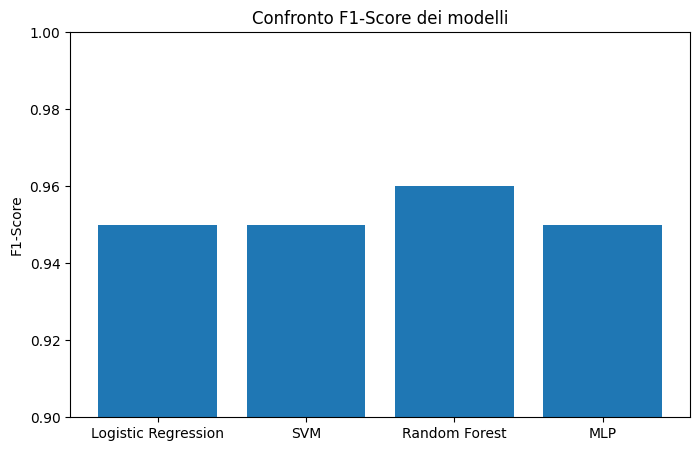

In [138]:
modelli = ['Logistic Regression', 'SVM', 'Random Forest', 'MLP']
f1 = [0.95, 0.95, 0.96, 0.95]

plt.figure(figsize=(8,5))
plt.bar(modelli, f1)
plt.title('Confronto F1-Score dei modelli')
plt.ylabel('F1-Score')
plt.ylim(0.90,1.00)
plt.show()

Osserviamo il grafico

Dal grafico si nota che tutti i modelli raggiungono prestazioni molto elevate. Tuttavia la Random Forest ottiene il valore di F1-Score più alto, dimostrando il miglior equilibrio tra Precision e Recall.

Confrontiamo le Confusion Matrix dei modelli

Per confrontare nel dettaglio le prestazioni dei quattro algoritmi, rappresentiamo la Confusion Matrix di ciascun modello. In questo modo possiamo osservare il numero di classificazioni corrette e gli errori commessi dai vari modelli.

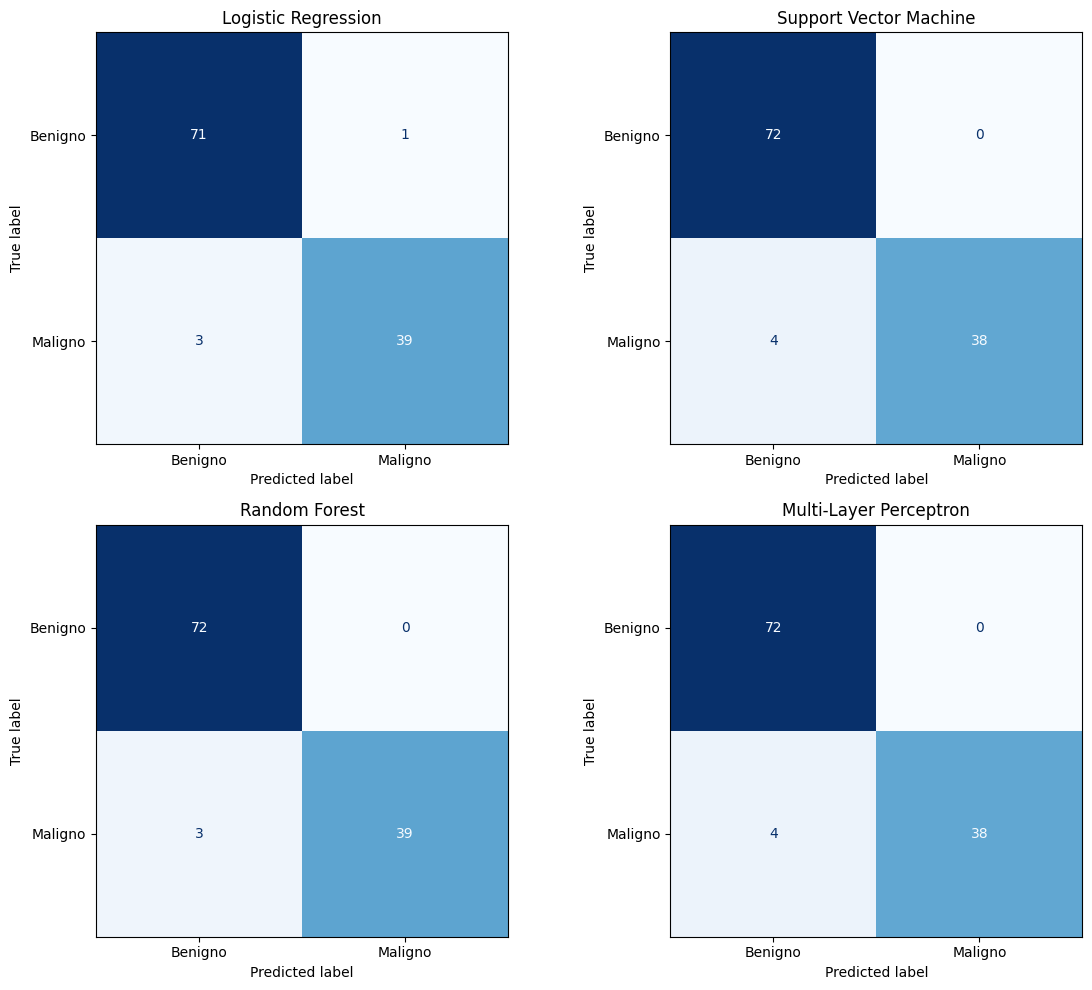

In [139]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Creiamo una figura con 4 grafici
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

modelli = [
    ("Logistic Regression", y_pred_lr),
    ("Support Vector Machine", y_pred_svm),
    ("Random Forest", y_pred_rf),
    ("Multi-Layer Perceptron", y_pred_mlp)
]

for ax, (nome, predizioni) in zip(axes.ravel(), modelli):

    cm = confusion_matrix(y_test, predizioni)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benigno", "Maligno"]
    )

    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nome)

plt.tight_layout()
plt.show()

Osserviamo le Confusion Matrix

Le quattro matrici confermano quanto emerso dalle metriche di valutazione. Tutti i modelli classificano correttamente la maggior parte dei pazienti, evidenziando un numero molto ridotto di errori.

In particolare, la Random Forest mostra la matrice più pulita, con il maggior numero di classificazioni corrette sulla diagonale principale e un numero minimo di errori. Anche la Logistic Regression e la Support Vector Machine ottengono risultati molto simili, mentre il Multi-Layer Perceptron presenta qualche errore in più nell'identificazione dei casi maligni(dovuto ad un dataset ridotto).

Poiché in ambito medico i falsi negativi rappresentano l'errore più critico, l'analisi delle Confusion Matrix conferma la scelta della Random Forest come modello più affidabile per questo problema.

Confronto tra modelli

I quattro algoritmi analizzati hanno ottenuto risultati molto simili, tutti superiori al 95% di Accuratezza.

La Logistic Regression ha dimostrato che le due classi risultano quasi linearmente separabili.

La Support Vector Machine, utilizzando un kernel lineare, ha confermato le prestazioni della Logistic Regression, mostrando un'elevata capacità di generalizzazione.

La Random Forest è risultata il modello migliore grazie alla sua robustezza nei confronti degli outlier e della correlazione tra le variabili, ottenendo il miglior F1-Score.

Il Multi-Layer Perceptron ha fornito ottimi risultati ma, a causa della limitata quantità di dati disponibili, non è riuscito a superare la Random Forest.

Interpretazione critica dei risultati

L'analisi delle prestazioni mostra come tutti i modelli siano in grado di distinguere efficacemente tumori benigni e maligni.

La fase di EDA aveva già evidenziato una buona separazione tra le classi attraverso le caratteristiche geometriche delle cellule, risultato poi confermato dai modelli di Machine Learning.

La Random Forest ha dimostrato di essere l'algoritmo più adatto a questo dataset, riuscendo a combinare elevata Precision, Recall e robustezza nei confronti di outlier e variabili correlate.

# 8. Conclusioni finali

Problema affrontato

L'obiettivo del progetto era sviluppare un sistema di classificazione in grado di distinguere tumori benigni e maligni utilizzando le caratteristiche geometriche dei nuclei cellulari presenti nel dataset Breast Cancer Wisconsin.

Metodo seguito

Il progetto è iniziato con una fase di analisi esplorativa dei dati (EDA), durante la quale sono stati analizzati la distribuzione delle classi, le caratteristiche principali del dataset e le correlazioni tra le variabili.

Successivamente sono state eliminate le colonne non necessarie, convertita la variabile target in formato numerico, identificati gli eventuali outlier mediante Z-Score e normalizzate le caratteristiche tramite StandardScaler.

Infine sono stati addestrati quattro differenti modelli di Machine Learning: Logistic Regression, Support Vector Machine, Random Forest e Multi-Layer Perceptron.

Risultati principali

Tutti i modelli hanno raggiunto prestazioni abbastanza elevate, dimostrando che le caratteristiche geometriche delle cellule consentono di distinguere efficacemente tumori benigni e maligni.

La Random Forest ha ottenuto i risultati migliori, raggiungendo il miglior equilibrio tra Precision, Recall e F1-Score e mostrando una maggiore robustezza rispetto agli altri algoritmi.

Conclusioni più importanti

L'analisi ha confermato quantitativamente quanto osservato in ambito clinico: le cellule maligne tendono ad avere dimensioni maggiori, una concavità più marcata e forme più irregolari rispetto alle cellule benigne.

I risultati ottenuti dimostrano inoltre che tecniche di Machine Learning possono rappresentare un valido supporto alla diagnosi medica, contribuendo a ridurre il numero di errori diagnostici e, in particolare, dei falsi negativi.

Eventuali limiti del lavoro svolto

Il principale limite del progetto è rappresentato dalla dimensione relativamente ridotta del dataset, costituito da poco più di cinquecento osservazioni, riscontrato soprattutto sul modello il Multi-Layer Perceptron
